<div style="background-color:#1a1a1a; padding:28px 32px; border-left:8px solid #D85A30;">
<h1 style="color:#ffffff; margin:0; font-family:Helvetica, Arial, sans-serif; font-weight:600;">Modelo logístico de crecimiento poblacional</h1>
<p style="color:#D85A30; margin:6px 0 0 0; font-family:Helvetica, Arial, sans-serif; font-size:15px;">Población de Costa Rica &mdash; Censos del INEC (1950&ndash;2022)</p>
</div>

<div style="border-left:4px solid #D85A30; padding:6px 16px; background-color:#fafafa;">
<p style="margin:0; color:#1a1a1a;">
Se ajusta un modelo logístico al crecimiento poblacional de Costa Rica, comparando los resultados teóricos con los datos censales del INEC.
</p>
</div>

<h1 style="color:#ffffff; background-color:#1a1a1a; padding:10px 16px; border-left:8px solid #D85A30; font-family:Helvetica, Arial, sans-serif;">Parte 1 &mdash; Análisis del modelo</h1>

## Modelo de referencia

El modelo logístico empleado es

$$P(t) = \frac{K}{1 + A\,e^{-rt}}$$

donde $P(t)$ es la población (en millones de habitantes) y $t$ son los años transcurridos desde 1950. Para el análisis a mano se utiliza el modelo de referencia con $K = 6$, $A = 7$ y $r = 0{,}05$.

**Datos reales (censos del INEC):**

| Año | 1950 | 1963 | 1973 | 1984 | 2000 | 2011 | 2022 |
|---|---|---|---|---|---|---|---|
| Población (millones) | 0,801 | 1,336 | 1,872 | 2,417 | 3,810 | 4,302 | 5,044 |

![Captura de pantalla 2026-06-27 221622.png](<attachment:Captura de pantalla 2026-06-27 221622.png>)
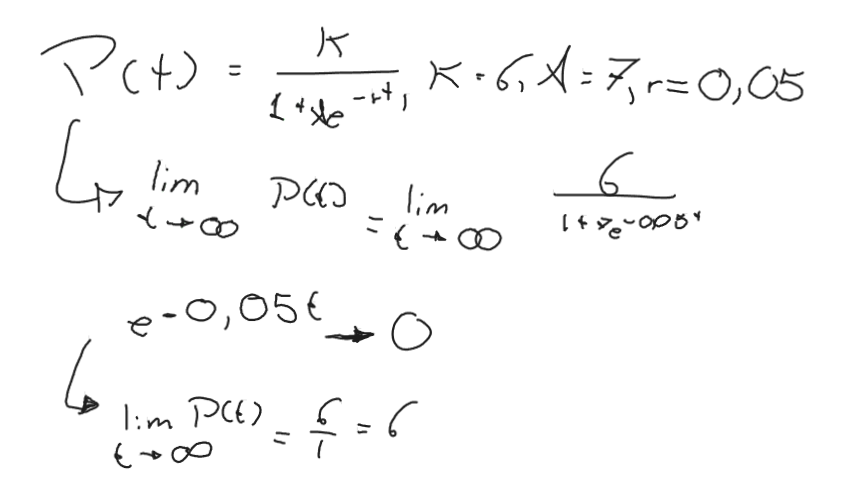

### 1.a &mdash; Comportamiento asintótico: $\displaystyle\lim_{t \to \infty} P(t)$

$$\lim_{t \to \infty} P(t) = \lim_{t \to \infty} \frac{K}{1+Ae^{-rt}}$$

Como $r = 0{,}05 > 0$, cuando $t \to \infty$ se tiene $e^{-rt} \to 0$, por lo que el denominador tiende a 1:

$$\lim_{t \to \infty} P(t) = \frac{K}{1} = K = 6$$

**Interpretación:** este valor es la **capacidad de carga**, el máximo poblacional que el modelo puede alcanzar. La población se acerca a $K$ con el tiempo pero nunca lo supera. En 2022 ya se registraban 5,044 millones, lo que indica que Costa Rica estaría entrando en la fase de desaceleración.

In [1]:
import numpy as np

K, A, r = 6.0, 7.0, 0.05

print("Verificación numérica de la asíntota K = 6")
for t in [0, 50, 100, 200, 500, 1000]:
    P = K / (1 + A * np.exp(-r * t))
    print(f"t = {t:5d}   P(t) = {P:.6f}")

Verificación numérica de la asíntota K = 6
t =     0   P(t) = 0.750000
t =    50   P(t) = 3.810504
t =   100   P(t) = 5.729753
t =   200   P(t) = 5.998094
t =   500   P(t) = 6.000000
t =  1000   P(t) = 6.000000


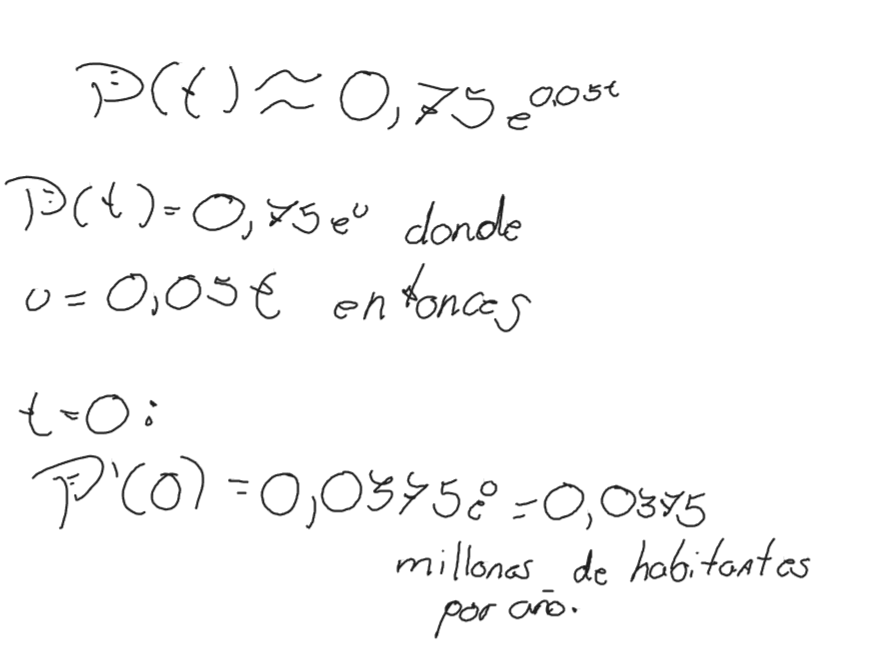

La tabla confirma el resultado: conforme $t$ aumenta, $P(t)$ converge a $K = 6$.

### 1.b &mdash; Regla de la cadena: $P'(t)$ y evaluación en $t = 0$

Con $P(t) = 0{,}75\,e^{u}$ y $u = 0{,}05t$, la regla de la cadena da:

$$P'(t) = 0{,}75\,e^{u} \cdot 0{,}05 = 0{,}0375\,e^{0{,}05t}$$

Evaluando en $t = 0$:

$$P'(0) = 0{,}0375 \text{ millones de habitantes/año}$$

**Interpretación:** en 1950 la población crecía a razón de **37 500 personas por año**. En esta fase inicial el modelo es casi exponencial puro porque $P \ll K$ y los recursos no limitan el crecimiento.

### 1.c &mdash; Valor de $P$ que maximiza la tasa de crecimiento

$$T(P) = rP\left(1 - \frac{P}{K}\right)$$

Derivando e igualando a cero:

$$T'(P) = r - \frac{2r}{K}P = 0 \implies \boxed{P^* = \frac{K}{2} = 3 \text{ millones}}$$

**Segunda derivada:** $T''(P) = -\dfrac{2r}{K} < 0$ &rarr; confirma que es un **máximo**.

**Interpretación:** el crecimiento es más rápido cuando la población llega a la mitad de la capacidad de carga. Según los censos, Costa Rica cruzó los 3 millones cerca del año 2000, que coincide con el período de mayor crecimiento en los datos del INEC.

<h1 style="color:#ffffff; background-color:#1a1a1a; padding:10px 16px; border-left:8px solid #D85A30; font-family:Helvetica, Arial, sans-serif;">Parte 2 &mdash; Interpretación conceptual</h1>

### 2.a &mdash; ¿Qué representa $P'(t)$ y en qué unidades se mide?

$P'(t)$ es la **tasa de crecimiento instantánea** de la población en el momento $t$: cuántos millones de habitantes se suman por año en ese instante exacto.

**Unidades:** millones de habitantes / año, ya que $P$ está en millones y $t$ en años. Un valor alto de $P'(t)$ significa que la población crece rápido en ese momento; un valor cercano a cero indica que el crecimiento se ha detenido.

### 2.b &mdash; ¿Por qué $P'(t) \to 0$ cuando $t \to \infty$?

La derivada del modelo logístico es:

$$P'(t) = \frac{K\,A\,r\,e^{-rt}}{\left(1+Ae^{-rt}\right)^{2}}$$

Cuando $t \to \infty$, $e^{-rt} \to 0$, lo que lleva al numerador a cero y por tanto $P'(t) \to 0$.

**Relación con la capacidad de carga:** al acercarse $P(t)$ a $K$, los recursos se vuelven limitantes y el crecimiento se frena. El modelo captura exactamente eso: menos margen disponible implica menor velocidad.

**Geometricamente:** $P'(t)$ es la pendiente de la recta tangente a la curva. Al inicio la curva sube con inclinación pronunciada; conforme se acerca a la asíntota $P = K$ se aplana, hasta que la tangente es prácticamente horizontal, es decir, pendiente $\approx 0$.

### 2.c &mdash; Función de costo y descenso de gradiente

**Función de costo (MSE):** mide qué tan alejadas están las predicciones del modelo respecto a los datos reales. Se calcula como el promedio de los errores al cuadrado:

$$J(K,A,r) = \frac{1}{n}\sum_{i=1}^{n}\left(P(t_i) - P_{\text{obs},i}\right)^{2}$$

Elevar al cuadrado evita que errores positivos y negativos se cancelen, y penaliza más los errores grandes. Se minimiza porque queremos los parámetros $K$, $A$ y $r$ que mejor se ajusten a los censos del INEC.

**Descenso de gradiente:** en cada iteración calcula el gradiente del costo respecto a cada parámetro y actualiza restando ese gradiente ponderado por la tasa de aprendizaje (`K -= lr * K.grad`). Así se avanza "cuesta abajo" en la superficie del error.

- **$lr$ muy grande:** pasos bruscos, el algoritmo puede oscilar o divergir.
- **$lr$ muy pequeña:** convergencia lenta, se necesitan muchas más iteraciones.

<h1 style="color:#ffffff; background-color:#1a1a1a; padding:10px 16px; border-left:8px solid #D85A30; font-family:Helvetica, Arial, sans-serif;">Parte 3 &mdash; Ajuste e implementación en Python</h1>

### 3.a &mdash; Modelo logístico y función de costo

Se define el modelo $\displaystyle P(t) = \frac{K}{1+Ae^{-rt}}$ y el costo como el error cuadrático medio entre las predicciones y los datos observados.

In [2]:
import numpy as np
import torch

# Datos del INEC (censos). Poblacion en millones, t en anios desde 1950.
anios = np.array([1950, 1963, 1973, 1984, 2000, 2011, 2022])
P_obs = np.array([0.801, 1.336, 1.872, 2.417, 3.810, 4.302, 5.044])

t = torch.tensor(anios - 1950, dtype=torch.float32)
P = torch.tensor(P_obs, dtype=torch.float32)

def modelo(t, K, A, r):
    return K / (1 + A * torch.exp(-r * t))

def costo(P_pred, P_real):
    return torch.mean((P_pred - P_real) ** 2)  # error cuadratico medio (MSE)

# --- Prueba con el modelo de referencia: K=6, A=7, r=0.05 ---
K_ref = torch.tensor(6.0)
A_ref = torch.tensor(7.0)
r_ref = torch.tensor(0.05)

P_pred = modelo(t, K_ref, A_ref, r_ref)
mse = costo(P_pred, P)

print("t (años desde 1950): ", t.tolist())
print("P_real:               ", [round(x, 3) for x in P.tolist()])
print("P_pred (modelo ref):  ", [round(x, 3) for x in P_pred.tolist()])
print("Costo (MSE):", round(mse.item(), 5))

t (años desde 1950):  [0.0, 13.0, 23.0, 34.0, 50.0, 61.0, 72.0]
P_real:                [0.801, 1.336, 1.872, 2.417, 3.81, 4.302, 5.044]
P_pred (modelo ref):   [0.75, 1.289, 1.865, 2.633, 3.811, 4.506, 5.037]
Costo (MSE): 0.01332


El modelo de referencia obtiene un MSE de $0{,}0133$. A continuación se ajustan los parámetros para reducir ese error.

### 3.b &mdash; Verificación de $P'(0)$ con SymPy y autograd

Se confirma el resultado analítico de la parte 1.b usando dos métodos computacionales:

$$P'(t) = 0{,}0375\,e^{0{,}05t} \implies P'(0) = 0{,}0375 \text{ millones/año}$$

In [3]:
import sympy as sp

# --- Método 1: derivada simbólica con SymPy ---
t_sym = sp.symbols('t')
P_exp = 0.75 * sp.exp(0.05 * t_sym)
dP_dt = sp.diff(P_exp, t_sym)
valor_sympy = float(dP_dt.subs(t_sym, 0))

print("P(t)          =", P_exp)
print("dP/dt         =", dP_dt)
print("dP/dt en t=0  =", round(valor_sympy, 4), "(SymPy)")

# --- Método 2: diferenciación automática con torch.autograd ---
t_torch = torch.tensor(0.0, requires_grad=True)
P_torch = 0.75 * torch.exp(0.05 * t_torch)
P_torch.backward()
valor_autograd = t_torch.grad.item()

print("dP/dt en t=0  =", round(valor_autograd, 4), "(autograd)")

# --- Comparación con el cálculo a mano ---
valor_mano = 0.75 * 0.05
print("\nValor a mano: 0.75 * 0.05 * e^0 =", round(valor_mano, 4))
print("¿Coincide con SymPy?   ", abs(valor_mano - valor_sympy) < 1e-9)
print("¿Coincide con autograd?", abs(valor_mano - valor_autograd) < 1e-6)

P(t)          = 0.75*exp(0.05*t)
dP/dt         = 0.0375*exp(0.05*t)
dP/dt en t=0  = 0.0375 (SymPy)
dP/dt en t=0  = 0.0375 (autograd)

Valor a mano: 0.75 * 0.05 * e^0 = 0.0375
¿Coincide con SymPy?    True
¿Coincide con autograd? True


Los tres métodos (a mano, SymPy y `torch.autograd`) coinciden en $P'(0) = 0{,}0375$ millones de habitantes por año.

### 3.c &mdash; Ajuste de parámetros con descenso de gradiente

Se optimizan $K$, $A$ y $r$ partiendo de los valores de referencia, minimizando el MSE con `autograd`. Se usa una tasa de aprendizaje baja ($lr = 0{,}0001$) para estabilidad, dado que los tres parámetros tienen gradientes de magnitud distinta.

In [4]:
# --- Parámetros iniciales: valores de referencia, con autograd activado ---
K = torch.tensor(6.0, requires_grad=True)
A = torch.tensor(7.0, requires_grad=True)
r = torch.tensor(0.05, requires_grad=True)

lr = 0.0001          # tasa de aprendizaje
n_epocas = 100000    # número de épocas

for epoca in range(n_epocas):
    P_pred = modelo(t, K, A, r)
    J = costo(P_pred, P)
    J.backward()

    with torch.no_grad():
        K -= lr * K.grad
        A -= lr * A.grad
        r -= lr * r.grad

    K.grad.zero_(); A.grad.zero_(); r.grad.zero_()

    if epoca % 20000 == 0:
        print(f"época {epoca:6d}   J = {J.item():.6f}   K={K.item():.4f}  A={A.item():.4f}  r={r.item():.4f}")

print("\n--- Parámetros finales ---")
print(f"K final = {K.item():.4f}")
print(f"A final = {A.item():.4f}")
print(f"r final = {r.item():.4f}")
print(f"Costo (MSE) final = {J.item():.6f}")

época      0   J = 0.013318   K=6.0000  A=7.0000  r=0.0493
época  20000   J = 0.008362   K=6.0191  A=7.0000  r=0.0484
época  40000   J = 0.008210   K=6.0381  A=7.0000  r=0.0482
época  60000   J = 0.008067   K=6.0572  A=7.0000  r=0.0480
época  80000   J = 0.007983   K=6.0691  A=7.0000  r=0.0479

--- Parámetros finales ---
K final = 6.0786
A final = 7.0000
r final = 0.0478
Costo (MSE) final = 0.007917


El costo baja de $0{,}01332$ a $0{,}00792$ con los parámetros ajustados, una mejora notable respecto al modelo de referencia.

### 3.d &mdash; Gráfica y predicción para 2030

Se grafica la curva ajustada junto con los datos del INEC, y se estima la población para el año 2030 ($t = 80$).

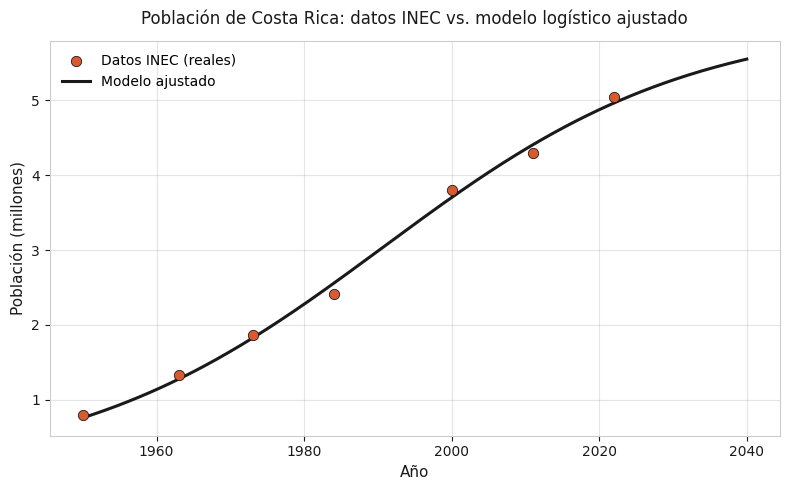


Predicción para el año 2030 (t=80): P ≈ 5.27 millones de habitantes


In [6]:
import matplotlib.pyplot as plt

# Paleta institucional
NARANJA = "#D85A30"
NEGRO   = "#1a1a1a"

t_cont = torch.linspace(0, 90, 300)
with torch.no_grad():
    P_cont = modelo(t_cont, K, A, r)

fig, ax = plt.subplots(figsize=(8, 5), facecolor="white")
ax.set_facecolor("white")

ax.scatter(anios, P_obs, color=NARANJA, s=55, zorder=3,
           edgecolor=NEGRO, linewidth=0.6, label="Datos INEC (reales)")
ax.plot(anios.min() + t_cont.numpy(), P_cont.numpy(), color=NEGRO,
         linewidth=2.2, label="Modelo ajustado")

ax.set_xlabel("Año", fontsize=11, color=NEGRO)
ax.set_ylabel("Población (millones)", fontsize=11, color=NEGRO)
ax.set_title("Población de Costa Rica: datos INEC vs. modelo logístico ajustado",
             fontsize=12, color=NEGRO, pad=12)
ax.tick_params(colors=NEGRO)
for spine in ax.spines.values():
    spine.set_color("#cccccc")
ax.grid(alpha=0.25, color="#999999")
ax.legend(frameon=False, fontsize=10)

plt.tight_layout()
plt.savefig("modelo_ajustado.png", dpi=150, facecolor="white")
plt.show()

# --- Predicción para el año 2030 (t = 80) ---
t_pred = torch.tensor(80.0)
with torch.no_grad():
    P_2030 = modelo(t_pred, K, A, r)

print(f"\nPredicción para el año 2030 (t=80): P ≈ {P_2030.item():.2f} millones de habitantes")

**Resultado:** con los parámetros ajustados ($K = 6{,}0786$, $A = 7{,}0000$, $r = 0{,}0478$), el modelo estima una población de **5,27 millones** para el año 2030.

El parámetro $A$ se movió muy poco durante el ajuste debido a diferencias en la magnitud de los gradientes. Un optimizador adaptativo como `Adam` permitiría un ajuste más equilibrado de los tres parámetros.